<a href="https://colab.research.google.com/github/Bee-Ene/Emotional-Speech-Manifolds/blob/main/RAVDESS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis of Emotional Speech Manifolds using Feature Learning, t-SNE and Spectral Clustering


In [ ]:
#!pip -q install librosa scikit-learn pandas matplotlib seaborn tqdm

In [ ]:
#imports
import os
import numpy as np
import pandas as pd
import shutil
import zipfile
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score, confusion_matrix, silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering

In [ ]:
#Loading dataset
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/MML_RAVDESS_Project'
ZIP_DRIVE_PATH = os.path.join(PROJECT_DIR, 'archive.zip')

EXTRACT_PATH = '/content/RAVDESS'
DATA_DIR = '/content/RAVDESS/audio_speech_actors_01-24'

os.makedirs(EXTRACT_PATH, exist_ok=True)

#extract iff not already extracted
if not os.path.exists(DATA_DIR):
  print("Extracting dataset from Drive...")
  with zipfile.ZipFile(ZIP_DRIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print("Dataset extracted to:", EXTRACT_PATH)

else:
  print("Dataset already extracted.")

#verify files
audio_files = []
for root, _, files in os.walk(EXTRACT_PATH):
  for f in files:
    if f.endswith(".wav"):
      audio_files.append(os.path.join(root, f))

print("Total WAV files found:", len(audio_files))
print("Sample:", audio_files[:3])

In [ ]:
#Extracting labels (RAVDESS structure)

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def get_label(path):
  filename = os.path.basename(path)
  return emotion_map[filename.split("-")[2]]

In [ ]:
data = []

for f in audio_files:
  try:
    parts = os.path.basename(f).split("-")

    if len(parts) != 7:
      continue

    data.append({
        "path": f,
        "emotion": emotion_map[parts[2]],
        "actor": parts[6]
    })

  except Exception as e:
    continue

df = pd.DataFrame(data)

print("Dataset size:", df.shape)
print(df["emotion"].value_counts())
print("Total samples in dataframe:", len(data))

Dataset size: (2880, 3)
emotion
calm         384
surprised    384
angry        384
happy        384
sad          384
disgust      384
fearful      384
neutral      192
Name: count, dtype: int64
Total samples in dataframe: 2880


In [ ]:
#Feature extraction

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    mean_mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40), axis=1)
    std_mfcc = np.std(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40), axis=1)
    mfcc = np.hstack([mean_mfcc, std_mfcc])
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    spectral = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)

    return np.hstack([mfcc, chroma, spectral])

In [ ]:
#Building feature matrix

X, y = [], []

for _, row in df.iterrows():
    try:
        X.append(extract_features(row["path"]))
        y.append(row["emotion"])
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (2880, 99)


In [ ]:
#Preprocessing

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
#PCA

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Explained variance: 0.8874577961278605


In [ ]:
#t-SNE

tsne = TSNE(n_components=2, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_pca)

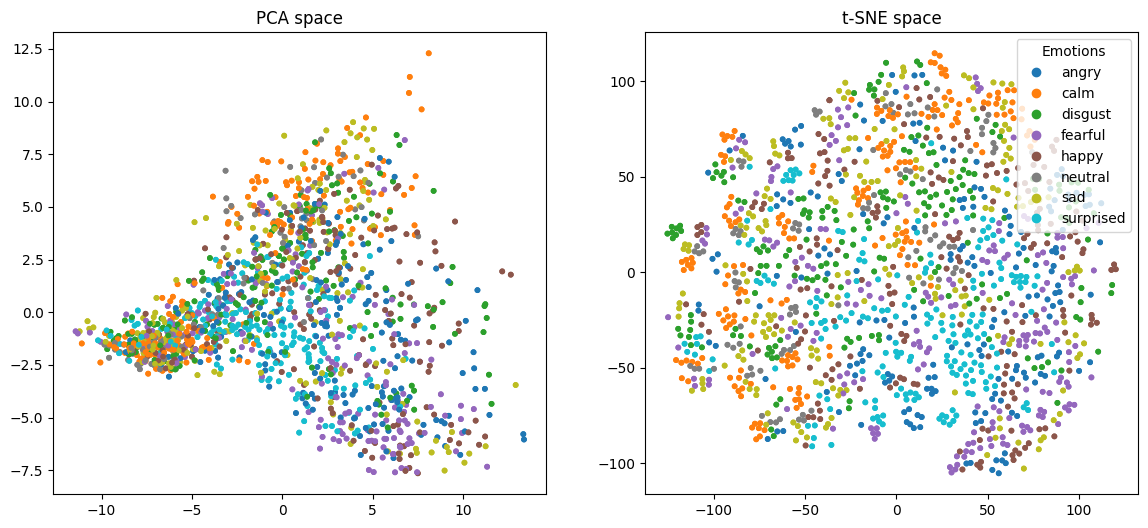

In [ ]:
#Visualization

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

scatter_pca = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap="tab10", s=10)
ax[0].set_title("PCA space")

scatter_tsne = ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_encoded, cmap="tab10", s=10)
ax[1].set_title("t-SNE space")

plt.legend(
    handles=scatter_tsne.legend_elements()[0],
    labels=list(encoder.classes_),
    title="Emotions"
)

plt.show()

In [ ]:
#Spectral Clustering

spectral = SpectralClustering(
    n_clusters=len(np.unique(y_encoded)),
    affinity="nearest_neighbors",
    n_neighbors=20,
    random_state=42
)

clusters = spectral.fit_predict(X_pca)

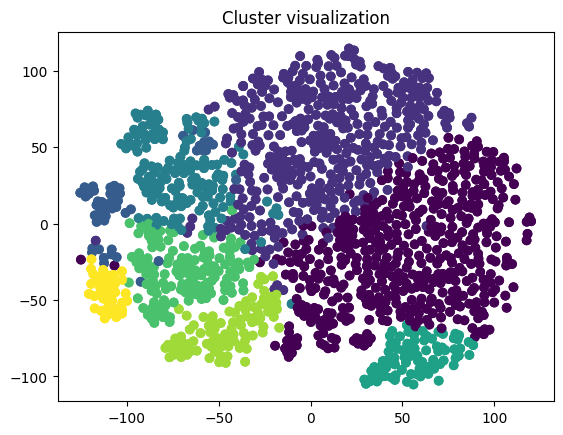

In [ ]:
#t-SNE cluster visualization
plt.scatter(
X_tsne[:,0],
X_tsne[:,1],
c=clusters
)
plt.title("Cluster visualization")
plt.show()

In [ ]:
#Adjusted Rand Index (ARI) Evaluation
ari = adjusted_rand_score(
y_encoded,
clusters)

print("Adjusted Rand Index: ", ari)

Adjusted Rand Index:  0.06185350810922397


In [ ]:
#silhouette score
sil= silhouette_score(
    X_pca,
    clusters
)

print("Silhouette score: ", sil)

Silhouette score:  0.0865550167679774
